# Experiment 3

Idea: mask true sensitive attribute label from algorithm

In [1]:
import copy
from typing import Optional

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from stable_baselines3.ppo import PPO

from config import (
    CALENDAR_SEED,
    DEMAND_MODEL_PRICE_GRANULARITY,
    FIGURES_PATH,
    N_SNAP_DAYS,
    NOISE_RANGE,
    NUM_PRODUCTS,
    NUM_TIMESTEPS,
    P_DIFF,
    P_MAX,
    P_MIN,
    PPO_HYPERPARAMS,
    PPO_TRAINING_EPISODES,
    RANDOM_SENS_PROBS_LIST,
    SEED_LIST,
    K,
)
from fair_dynamic_pricing_with_rl.utils.demand_model import DemandModelEstimator
from fair_dynamic_pricing_with_rl.utils.env import FMCGEnv
from fair_dynamic_pricing_with_rl.utils.experiment_utils import argmedian
from fair_dynamic_pricing_with_rl.utils.fairness_utils import compute_jains_index


In [2]:
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
calendar = pd.read_csv("../data/calendar.csv")

In [3]:
demand_model_estimator = DemandModelEstimator(
    unit_sales_df = unit_sales,
    prices_df = prices,
    calendar_df = calendar,
    price_granularity = DEMAND_MODEL_PRICE_GRANULARITY,
    verbose = False # demand parameters were shown in experiment 1
)

demand_model_parameters = demand_model_estimator.run_pipeline()

/Users/kisslucasara/Documents/levi-research-project/newest_codes/fair-dynamic-pricing-with-rl/src/fair_dynamic_pricing_with_rl/utils/demand_model.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  q = foods_demand.groupby(by=["item_id"]).mean().reset_index()
/Users/kisslucasara/Documents/levi-research-project/newest_codes/fair-dynamic-pricing-with-rl/src/fair_dynamic_pricing_with_rl/utils/demand_model.py:120: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  q_long = q.reset_index().melt(


## New environment with sensitive attribute inversion

In [4]:
class FMCGEnv3(FMCGEnv):
    def __init__(
        self,
        p_min: np.ndarray,
        p_max: np.ndarray,
        p_diff: np.ndarray,
        betas: list,
        noise_range: int,
        max_demand: int,
        n_snap_days: int,
        calendar_seed=None,
        T: int = 60,
        random_sens_prob: float = 0.5,
    ):
        """Initialize FMCG Gymnasium environment.

        Args:
            p_min (np.array): minimum price vector of products (L)
            p_max (np.array): maximum price vector of products (L)
            p_diff (np.array): price step vector of products (L)
            betas (List[np.ndarray]): demand core state param. for non-SNAP and SNAP households
            noise_range (int): maximum value of noise (symmetric)
            max_demand (int): the maximum daily demand considering all L products
            n_snap_days (int): number of SNAP days in a 30-day month.
            calendar_seed (int, optional): seed used for constructing SNAP calendar
            T (int, optional): length of episode (defaults to 60),
            random_sens_prob (float): probability of inverting sensitive attribute (default: 0.5)
        """
        super().__init__(p_min, p_max,p_diff,
                         betas, noise_range, max_demand, n_snap_days, calendar_seed,
                         T)
        self._random_sens_prob = random_sens_prob

        # s is a deterministic function of t, omitting t
        self.observation_space = gym.spaces.Dict(
            {
                "demand": gym.spaces.Box(
                    low=0.0, high=1.0, shape=(self.L,), dtype=np.float32
                ),
                # "t": gym.spaces.Discrete(self.T),
                "sensitive_attr": gym.spaces.Discrete(2),
            }
        )

    def reset(self,
              seed: Optional[int] = None,
              options: Optional[dict] = None):
        """Start a new episode.

        Args:
            seed: Random seed for reproducible episodes
            options: Additional configuration

        Returns:
            tuple: (observation, info) for the initial state
        """
        if seed is not None:
            self._flip_rng = np.random.default_rng(np.random.SeedSequence([seed, 1]))
        elif not hasattr(self, "_flip_rng"):
            self._flip_rng = np.random.default_rng()

        # one Bernoulli draw per timestep, fixed for the whole episode
        self._flips = self._flip_rng.random(self.T) < self._random_sens_prob

        # perform FMCGEnv reset
        return super().reset(seed=seed, options=options)

    def _t_to_randomized_sens_attr(
            self,
            t: int,
        ):
            """Returns the sensitive attribute at t, with self.random_sens_attr prob.
            returns the opposite label.
            Args:
                t (int): time step index
    
            Returns
                sensitive attribute: (potentially inversed) sensitive attribute at t (0/1)
            """
            # get true sensitive attribute and get random number
            sens_attr = self.mask[(np.asarray(t)) % 30].astype(int)
            flip = bool(self._flips[t % self.T])

            # (potentially) invert label
            if flip:
                sens_attr = 1 - sens_attr

            return sens_attr

    def _get_obs(self):
        """Convert internal state to observation format.

        Returns:
            obs (dict): Observation with demand and time point
        """
        # apply min-max scaling to demand
        demand_out = (self._demand / self._max_demand).astype(np.float32)

        # s is a deterministic function of t, omitting t
        return {
            "demand": demand_out,
            # "t": int(self._t),
            "sensitive_attr": int(self._t_to_randomized_sens_attr(self._t)),
        }

    def _get_info(self):
        return {"sensitive_attr": int(self._t_to_sens_attr(self._t))}

In [5]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv3",
    entry_point=FMCGEnv3,
    max_episode_steps=500,  # Prevent infinite episodes
)

In [6]:
def running_model(env1,
                  alg,
                  T,
                  K,
                  num_products,
                  seed=None
                  ):
    """ Running PPO algorithm

    Args:
        env1 (FMCGEnv3): the defined gym environment
        alg (stable_baselines3.PPO): PPO policy
        T (int): number of timesteps per episode
        K (int): number of episodes
        num_products (int): number of products
        seed (int): seed for reproducibility

    Returns:
        rew (np.ndarray): rewards (T,K)
        action_hist (np.ndarray): action history (T,K,L)
        groups (np.ndarray): groups according to binary sensitive attribute (T,K)
    """

    env = copy.deepcopy(env1)

    rew = np.zeros((T,K))
    action_hist = np.zeros((T,K,num_products))
    groups = np.zeros((T,K))

    for k in range(K):
        # sample initial state
        # seed each reset deterministically but distinctly per episode
        observation, info = env.reset(seed=None if seed is None else seed + k)

        for t in range(T):
            # get the true sensitive attribute not the (possibly) masked observation
            groups[t,k] = info['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation, deterministic=False)
            a = np.asarray(action)
            
            action_hist[t,k] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)

            rew[t,k] = reward
        
    return rew, action_hist, groups

In [7]:
# storing expected mean episode rewards
episode_rewards_comparison = np.zeros((K*len(RANDOM_SENS_PROBS_LIST),3))
# storing Jain's indexes and mean episode revenues
results = pd.DataFrame(np.zeros((len(RANDOM_SENS_PROBS_LIST),4)),
                       columns=["mean_episode_revenue","jains_index", "nonsnap_price", "snap_price"])

rewards_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K))
action_hist_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K,NUM_PRODUCTS))
groups_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K))

for idx in range(len(RANDOM_SENS_PROBS_LIST)):
    print(f"RUN STARTED FOR MASKING PROB. = {RANDOM_SENS_PROBS_LIST[idx]}")
    for seed_idx in range(len(SEED_LIST)):
        print(f"RUN STARTED FOR SEED {SEED_LIST[seed_idx]}")
        # make environment with chosen prob. of inverted sens attr.
        env = gym.make("gymnasium_env/FMCGEnv3",
                p_min=P_MIN,
                p_max=P_MAX,
                p_diff=P_DIFF,
                betas=[params.to_numpy() for params in demand_model_parameters[3]],
                max_demand=demand_model_parameters[4],
                n_snap_days=N_SNAP_DAYS,
                calendar_seed=CALENDAR_SEED,
                noise_range=NOISE_RANGE,
                T=NUM_TIMESTEPS,
                random_sens_prob=RANDOM_SENS_PROBS_LIST[idx],
                )

        # define and warm-up algorithm
        # PPO hyperparameters from Liu et al. (2024)
        model = PPO(policy="MultiInputPolicy",
                    env=env,
                    learning_rate=PPO_HYPERPARAMS["learning_rate"],
                    batch_size=PPO_HYPERPARAMS["batch_size"], # default
                    clip_range=PPO_HYPERPARAMS["clip_range"], # default
                    seed=SEED_LIST[seed_idx],
                    ent_coef=PPO_HYPERPARAMS["ent_coef"],
                    )

        model.learn(total_timesteps=PPO_TRAINING_EPISODES*NUM_TIMESTEPS,
                    progress_bar=True)

        rewards, action_hist, groups = running_model(env1=env,
                                                alg=model,
                                                T=NUM_TIMESTEPS,
                                                K=K,
                                                num_products=NUM_PRODUCTS,
                                                seed=SEED_LIST[seed_idx])

        rewards_over_seeds[seed_idx, ...] = rewards
        action_hist_over_seeds[seed_idx, ...] = action_hist
        groups_over_seeds[seed_idx, ...] = groups

    # save _over_seeds arrays for further analysis
    np.save(f"../output/experiment_3/rewards_over_seeds_{RANDOM_SENS_PROBS_LIST[idx]}.npy",
            rewards_over_seeds)
    np.save(f"../output/experiment_3/action_hist_over_seeds_{RANDOM_SENS_PROBS_LIST[idx]}.npy",
            action_hist_over_seeds)
    np.save(f"../output/experiment_3/groups_over_seeds_{RANDOM_SENS_PROBS_LIST[idx]}.npy",
            groups_over_seeds)

    # choose based on median of last episode reward
    last_episode_rewards_over_seeds = rewards_over_seeds.sum(axis=1)[:,-1]
    median_seed_idx = argmedian(last_episode_rewards_over_seeds)

    rewards_chosen = rewards_over_seeds[median_seed_idx,...]
    action_hist_chosen = action_hist_over_seeds[median_seed_idx,...]
    groups_chosen = groups_over_seeds[median_seed_idx,...]
    
    episode_rewards = rewards_chosen.sum(axis=0)
    e_mean_episode_reward = episode_rewards.cumsum() / (np.arange(K) + 1)

    # expected mean episode rewards
    episode_rewards_comparison[(idx*K):((idx+1)*K),0] = np.arange(K)
    episode_rewards_comparison[(idx*K):((idx+1)*K),1] = e_mean_episode_reward

    # random action probability
    episode_rewards_comparison[(idx*K):((idx+1)*K),2] = RANDOM_SENS_PROBS_LIST[idx]

    # save main performance metrics
    results.loc[idx,"random_sens_prob"] = RANDOM_SENS_PROBS_LIST[idx]
    results.loc[idx,"mean_episode_revenue"] = episode_rewards.mean()
    results.loc[idx, "jains_index"], group_values = compute_jains_index(action_hist_chosen,
                                                                        groups_chosen,
                                                                        p_min=P_MIN,
                                                                        p_diff=P_DIFF)
    results.loc[idx, "nonsnap_price"] = group_values[False]
    results.loc[idx, "snap_price"] = group_values[True]
    print(f"Iteration done with mean episode revenue of {episode_rewards.mean()} and Jain's index of {results.loc[idx, "jains_index"]}.")
    print(f"Average price differences: non-SNAP: {group_values[False]} vs. SNAP: {group_values[True]}")

RUN STARTED FOR MASKING PROB. = 0.0
RUN STARTED FOR SEED 1024


Output()

Output()

RUN STARTED FOR SEED 1224


Output()

...

Output()

RUN STARTED FOR SEED 1224


Output()

RUN STARTED FOR SEED 1424


Iteration done with mean episode revenue of 8740.172022922487 and Jain's index of 0.9999802306738144.
Average price differences: non-SNAP: 16.46737 vs. SNAP: 16.321579999999997


In [8]:
# save & print results, note the Windows-specific path(!)
results.to_csv("../output/experiment_3/results.csv",
               index=False)
results

,mean_episode_revenue,jains_index,nonsnap_price,snap_price,random_sens_prob
0,9608.262326,0.999968,16.678183,16.489830,0.000000
1,8791.574983,0.999998,16.454553,16.409040,0.111111
2,9376.507356,1.000000,16.506654,16.495652,0.222222
3,9640.257150,1.000000,16.510790,16.509217,0.333333
4,9385.693487,1.000000,16.463291,16.472980,0.444444
5,9198.452372,1.000000,16.469271,16.480078,0.555556
6,9342.009300,1.000000,16.606817,16.595412,0.666667
7,9929.161052,1.000000,16.684979,16.662220,0.777778
8,9973.893300,0.999996,16.701125,16.635785,0.888889
9,8740.172023,0.999980,16.467370,16.321580,1.000000


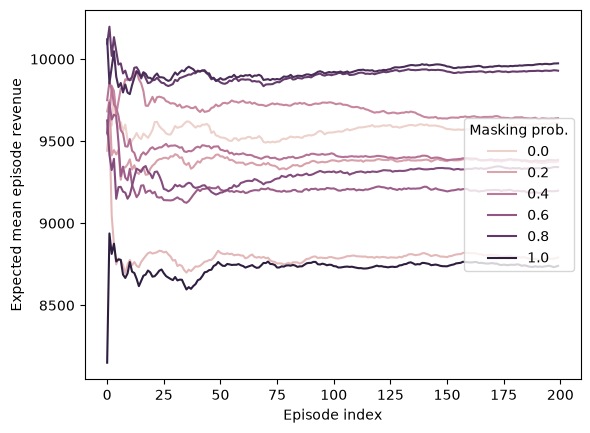

In [9]:
episode_rewards_comparison_df = pd.DataFrame(episode_rewards_comparison,
                                             columns=["episode_idx", "mean_episode_revenue", "random_sens_prob"])

# for plotting every episode ex. first x: data = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx > 50.0],
sns.lineplot(data = episode_rewards_comparison_df,
             x="episode_idx",
             y="mean_episode_revenue",
             hue="random_sens_prob")
plt.xlabel("Episode index")
plt.ylabel("Expected mean episode revenue")
plt.legend(title="Masking prob.", loc="center right")
plt.savefig(FIGURES_PATH + "experiment_3_revenue_over_time.pdf", format="pdf", bbox_inches="tight")

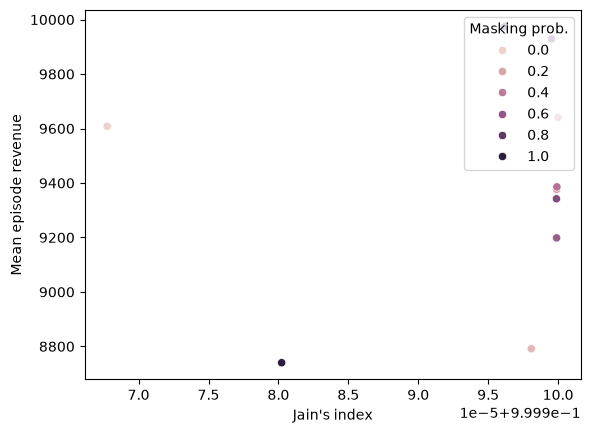

In [10]:
sns.scatterplot(data=results, x="jains_index", y="mean_episode_revenue",
                hue="random_sens_prob")
plt.xlabel("Jain's index")
plt.ylabel("Mean episode revenue")
plt.legend(title="Masking prob.", loc="upper right")
plt.savefig(FIGURES_PATH + "experiment_3_revenue_vs_jains.pdf", format="pdf", bbox_inches="tight")